# 正则化实验：L2 正则化与 Dropout 🛡️

欢迎来到本次实验！深度学习模型具有强大的表达能力，但也很容易对训练集过拟合。
本实验将通过一个**网络流量异常检测**场景，帮助你掌握两种主流正则化技术：

**学习目标：**
- 理解 L2 正则化的原理，并在代价函数与反向传播中实现它
- 理解 Dropout 正则化的原理，并在前向传播与反向传播中实现它
- 观察正则化对模型过拟合的抑制效果


## 目录
- [1 - 导入工具包](#1)
- [2 - 问题描述](#2)
- [3 - 无正则化的基线模型](#3)
- [4 - L2 正则化](#4)
  - [4.1 - 带正则化的代价函数（练习 1）](#4-1)
  - [4.2 - 带正则化的反向传播（练习 2）](#4-2)
- [5 - Dropout 正则化](#5)
  - [5.1 - 带 Dropout 的前向传播（练习 3）](#5-1)
  - [5.2 - 带 Dropout 的反向传播（练习 4）](#5-2)
- [6 - 总结与对比](#6)


<a name='1'></a>
## 1 - 导入工具包

In [21]:
### v1.0

In [22]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = [
    'PingFang SC',        # macOS
    'Hiragino Sans GB',   # macOS（备用）
    'Microsoft YaHei',    # Windows
    'SimHei',             # Windows（备用）
    'Noto Sans CJK SC',   # Linux / 通用
    'Arial Unicode MS'    # 兜底
]

plt.rcParams['axes.unicode_minus'] = False

In [23]:
# 导入所需工具包
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import scipy.io

from reg_utils import sigmoid, relu, plot_decision_boundary, initialize_parameters, load_2D_dataset, predict_dec
from reg_utils import compute_cost, predict, forward_propagation, backward_propagation, update_parameters
from testCases_reg import *
from public_tests_reg import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (7.0, 4.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

<a name='2'></a>
## 2 - 问题描述

某互联网安全公司正在构建一套**网络流量异常检测系统**，希望通过机器学习自动识别网络中的异常流量（如 DDoS 攻击、端口扫描等）。

数据集中的每个样本代表一条网络连接记录，包含两个归一化特征：
- **特征 1（x1）**：连接的数据包速率
- **特征 2（x2）**：连接的字节率

标签定义：
- **0（蓝色）**：正常流量
- **1（红色）**：异常流量

你的任务是训练一个分类器，在保持高测试准确率的同时避免过拟合。

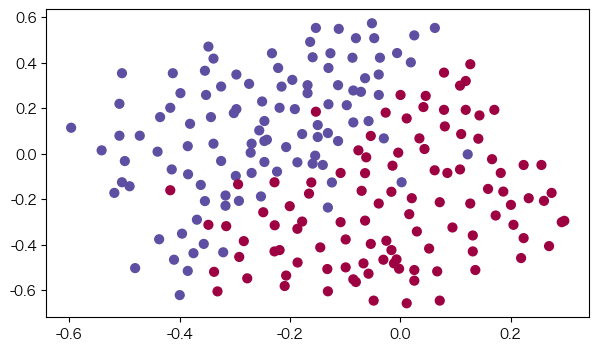

In [24]:
train_X, train_Y, test_X, test_Y = load_2D_dataset()

<a name='3'></a>
## 3 - 无正则化的基线模型

我们首先训练一个**没有任何正则化**的三层神经网络，观察其是否出现过拟合。

网络结构：`INPUT(2) → LINEAR(20) → RELU → LINEAR(3) → RELU → LINEAR(1) → SIGMOID`

下面的 `model()` 函数已经为你实现好了，它支持三种模式：
- 无正则化（默认，`lambd=0, keep_prob=1`）
- L2 正则化（设置 `lambd > 0`）
- Dropout 正则化（设置 `keep_prob < 1`）

In [25]:
def model(X, Y, learning_rate=0.3, num_iterations=30000, print_cost=True, lambd=0, keep_prob=1):
    """
    三层神经网络训练函数，支持 L2 正则化与 Dropout 正则化。

    参数：
    X              -- 输入数据，形状 (2, 样本数)
    Y              -- 标签，形状 (1, 样本数)
    learning_rate  -- 学习率
    num_iterations -- 迭代次数
    print_cost     -- 是否打印损失
    lambd          -- L2 正则化超参数（0 表示不使用）
    keep_prob      -- Dropout 保留概率（1 表示不使用 Dropout）

    返回：
    parameters -- 训练后的模型参数
    """
    grads = {}
    costs = []
    m = X.shape[1]
    layers_dims = [X.shape[0], 20, 3, 1]

    parameters = initialize_parameters(layers_dims)

    for i in range(num_iterations):
        if keep_prob == 1:
            a3, cache = forward_propagation(X, parameters)
        elif keep_prob < 1:
            a3, cache = forward_propagation_with_dropout(X, parameters, keep_prob)

        if lambd == 0:
            cost = compute_cost(a3, Y)
        else:
            cost = compute_cost_with_regularization(a3, Y, parameters, lambd)

        assert lambd == 0 or keep_prob == 1, 'Currently, using both L2 regularization and Dropout is not supported.'

        if lambd == 0 and keep_prob == 1:
            grads = backward_propagation(X, Y, cache)
        elif lambd != 0:
            grads = backward_propagation_with_regularization(X, Y, cache, lambd)
        elif keep_prob < 1:
            grads = backward_propagation_with_dropout(X, Y, cache, keep_prob)

        parameters = update_parameters(parameters, grads, learning_rate)

        if print_cost and i % 10000 == 0:
            print('第 %i 次迭代，损失值：%f' % (i, cost))
        if print_cost and i % 1000 == 0:
            costs.append(cost)

    plt.plot(costs)
    plt.ylabel('Cost')
    plt.xlabel('Iterations (x1000)')
    plt.title('Learning rate = ' + str(learning_rate))
    plt.show()

    return parameters

我们先不使用任何正则化，训练基线模型，观察训练集与测试集的准确率差异。

第 0 次迭代，损失值：0.655741
第 10000 次迭代，损失值：0.163300
第 20000 次迭代，损失值：0.138516


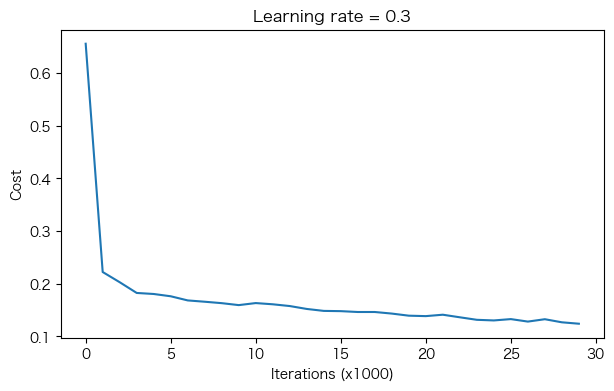

Train set:
准确率: 0.9478672985781991
Test set:
准确率: 0.915


In [26]:
# 不强制使用中文字体，避免 SimHei 缺失报错
plt.rcParams['axes.unicode_minus'] = False  # 负号正常显示

parameters = model(train_X, train_Y)
print('Train set:')
predictions_train = predict(train_X, train_Y, parameters)
print('Test set:')
predictions_test = predict(test_X, test_Y, parameters)


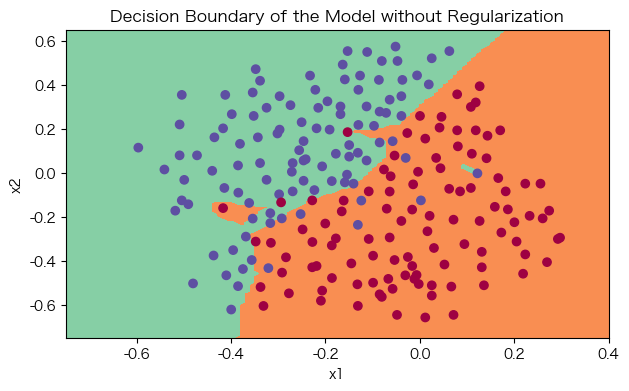

In [27]:
plt.title('Decision Boundary of the Model without Regularization')
axes = plt.gca()
axes.set_xlim([-0.75, 0.40])
axes.set_ylim([-0.75, 0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y[0, :])

<a name='4'></a>
## 4 - L2 正则化

**L2 正则化**（也称权重衰减）通过在代价函数中加入参数的 L2 范数惩罚项来防止过拟合。

带 L2 正则化的代价函数为：

$$J_{\text{正则化}} = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1-y^{(i)}) \log(1-\hat{y}^{(i)}) \right] + \frac{\lambda}{2m} \left( \|W^{[1]}\|_F^2 + \|W^{[2]}\|_F^2 + \|W^{[3]}\|_F^2 \right)$$

其中 $\|W\|_F^2 = \sum_{i,j} W_{ij}^2$ 为 Frobenius 范数的平方，$\lambda$ 为正则化超参数。

<a name='4-1'></a>
### 4.1 - 带正则化的代价函数

<a name='ex-1'></a>
### 练习 1 - compute_cost_with_regularization

请实现带 L2 正则化的代价函数。

**提示：**
- 在普通交叉熵代价的基础上，加上三个权重矩阵的 Frobenius 范数之和
- `np.sum(np.square(W))` 可以计算矩阵所有元素的平方和
- 正则化项为 $\frac{\lambda}{2m}(\|W^{[1]}\|_F^2 + \|W^{[2]}\|_F^2 + \|W^{[3]}\|_F^2)$
- 从 `parameters` 字典中提取 `W1`、`W2`、`W3`

In [28]:
# GRADED FUNCTION: compute_cost_with_regularization

def compute_cost_with_regularization(A3, Y, parameters, lambd):
    """
    实现带 L2 正则化的代价函数，公式见实验讲义。

    参数：
    A3         -- 前向传播的输出（预测概率），形状 (1, 样本数)
    Y          -- 真实标签，形状 (1, 样本数)
    parameters -- 包含 W1, W2, W3 的参数字典
    lambd      -- 正则化超参数（标量）

    返回：
    cost -- 包含正则化惩罚项的代价值
    """
    m = Y.shape[1]
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    W3 = parameters["W3"]

    cross_entropy_cost = compute_cost(A3, Y)

    ### START CODE HERE ###
    ### END CODE HERE ###

    cost = cross_entropy_cost + L2_regularization_cost

    return cost

In [29]:
A3, t_Y, parameters = compute_cost_with_regularization_test_case()
cost = compute_cost_with_regularization(A3, t_Y, parameters, lambd=0.1)
print('带正则化的代价值 =', cost)

compute_cost_with_regularization_test(compute_cost_with_regularization)

带正则化的代价值 = 1.7864859451590758
 All tests passed.


<a name='4-2'></a>
### 4.2 - 带正则化的反向传播

<a name='ex-2'></a>
### 练习 2 - backward_propagation_with_regularization

修改代价函数后，需要同步修改反向传播，对 $dW$ 加入正则化梯度项。

**L2 正则化对梯度的影响：**

$$dW^{[l]} = \underbrace{\frac{\partial \mathcal{L}}{\partial W^{[l]}}\big|_{\text{原始}}}_{\text{无正则化}} + \frac{\lambda}{m} W^{[l]}$$

**提示：**
- 只需在原始 `dW1`、`dW2`、`dW3` 上分别加上 `(lambd / m) * W1` 等项
- `db` 不受 L2 正则化影响，保持不变
- 从 `cache` 元组中解包出 `(Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3)`

In [30]:
# GRADED FUNCTION: backward_propagation_with_regularization

def backward_propagation_with_regularization(X, Y, cache, lambd):
    """
    实现带 L2 正则化的反向传播。

    参数：
    X     -- 输入数据，形状 (输入维度, 样本数)
    Y     -- 真实标签，形状 (1, 样本数)
    cache -- forward_propagation() 返回的缓存元组
    lambd -- 正则化超参数

    返回：
    gradients -- 包含各参数梯度的字典
    """
    m = X.shape[1]
    (Z1, A1, W1, b1, Z2, A2, W2, b2, Z3, A3, W3, b3) = cache

    dZ3 = A3 - Y

    ### START CODE HERE ###


    ### END CODE HERE ###

    gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3,
                 "dA2": dA2, "dZ2": dZ2, "dW2": dW2, "db2": db2,
                 "dA1": dA1, "dZ1": dZ1, "dW1": dW1, "db1": db1}

    return gradients

In [31]:
t_X, t_Y, cache = backward_propagation_with_regularization_test_case()
grads = backward_propagation_with_regularization(t_X, t_Y, cache, lambd=0.7)
print('dW1 =', grads['dW1'])
print('dW2 =', grads['dW2'])
print('dW3 =', grads['dW3'])

backward_propagation_with_regularization_test(backward_propagation_with_regularization)

dW1 = [[-0.25604646  0.12298827 -0.28297129]
 [-0.17706303  0.34536094 -0.4410571 ]]
dW2 = [[ 0.79276486  0.85133918]
 [-0.0957219  -0.01720463]
 [-0.13100772 -0.03750433]]
dW3 = [[-1.77691347 -0.11832879 -0.09397446]]
 All tests passed.


现在用 L2 正则化（$\lambda = 0.7$）训练模型，`model()` 函数会自动调用你刚刚实现的两个函数。

第 0 次迭代，损失值：0.697448
第 10000 次迭代，损失值：0.268492
第 20000 次迭代，损失值：0.268092


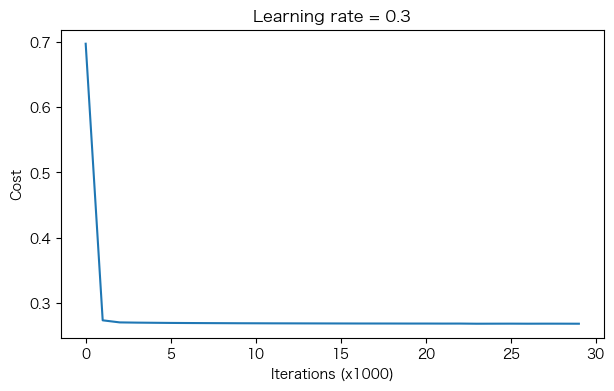

训练集：
准确率: 0.9383886255924171
测试集：
准确率: 0.93


In [32]:
parameters = model(train_X, train_Y, lambd=0.7)
print('训练集：')
predictions_train = predict(train_X, train_Y, parameters)
print('测试集：')
predictions_test = predict(test_X, test_Y, parameters)

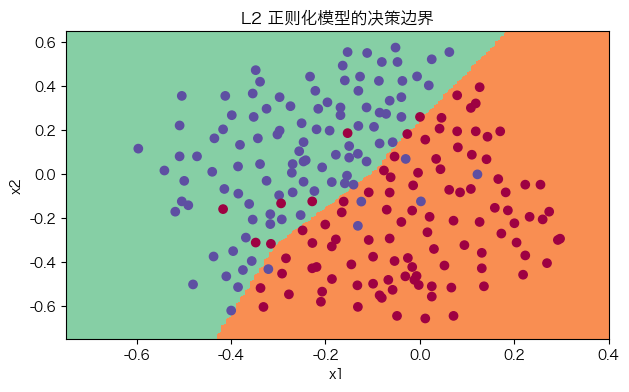

In [33]:
plt.title('L2 正则化模型的决策边界')
axes = plt.gca()
axes.set_xlim([-0.75, 0.40])
axes.set_ylim([-0.75, 0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y[0, :])

<a name='5'></a>
## 5 - Dropout 正则化

**Dropout** 是一种专为神经网络设计的正则化技术。
在训练每一步中，它会以概率 $(1 - \text{keep\_prob})$ 随机关闭（置零）每层的若干神经元，
强迫网络学习更鲁棒、分散的特征表示，从而减少过拟合。

**关键要点：**
1. **训练阶段**：随机关闭神经元，并对剩余激活值除以 `keep_prob` 进行缩放，以维持期望值不变
2. **测试阶段**：不使用 Dropout（`keep_prob=1`），使用所有神经元
3. 每次迭代的 Dropout 掩码都是独立随机生成的

<a name='5-1'></a>
### 5.1 - 带 Dropout 的前向传播

<a name='ex-3'></a>
### 练习 3 - forward_propagation_with_dropout

请在第 1、2 层激活后应用 Dropout（第 3 层不使用 Dropout）。

**每一层 Dropout 的步骤（以第 1 层为例）：**

1. 生成与 `A1` 形状相同的随机矩阵：`D1 = np.random.rand(A1.shape[0], A1.shape[1])`
2. 将 `D1` 转换为布尔掩码：`D1 = (D1 < keep_prob)`
3. 应用掩码关闭神经元：`A1 = A1 * D1`
4. 对激活值缩放（反向 Dropout）：`A1 = A1 / keep_prob`

**注意：** 需将掩码 `D1`、`D2` 存入 `cache`，供反向传播使用。

In [34]:
# GRADED FUNCTION: forward_propagation_with_dropout

def forward_propagation_with_dropout(X, parameters, keep_prob=0.5):
    """
    实现带 Dropout 正则化的前向传播（第 1、2 层应用 Dropout）。

    参数：
    X          -- 输入数据，形状 (2, 样本数)
    parameters -- 包含 W1,b1,W2,b2,W3,b3 的参数字典
    keep_prob  -- 神经元保留概率，标量（0 < keep_prob <= 1）

    返回：
    A3    -- 最后一层的激活输出
    cache -- 包含 Dropout 掩码的缓存元组，供反向传播使用
    """
    np.random.seed(1)

    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
    W3 = parameters["W3"]
    b3 = parameters["b3"]

    # 第一层：LINEAR -> RELU -> DROPOUT
    Z1 = np.dot(W1, X) + b1
    A1 = relu(Z1)
    ### START CODE HERE ###
    ### END CODE HERE ###

    # 第二层：LINEAR -> RELU -> DROPOUT
    Z2 = np.dot(W2, A1) + b2
    A2 = relu(Z2)
    ### START CODE HERE ###
    ### END CODE HERE ###

    # 第三层：LINEAR -> SIGMOID（不使用 Dropout）
    Z3 = np.dot(W3, A2) + b3
    A3 = sigmoid(Z3)

    cache = (Z1, D1, A1, W1, b1, Z2, D2, A2, W2, b2, Z3, A3, W3, b3)

    return A3, cache

In [35]:
t_X, parameters = forward_propagation_with_dropout_test_case()
A3, cache = forward_propagation_with_dropout(t_X, parameters, keep_prob=0.7)
print('A3 =', A3)

forward_propagation_with_dropout_test(forward_propagation_with_dropout)

A3 = [[0.36974721 0.00305176 0.04565099 0.49683389 0.36974721]]
 All tests passed.


<a name='5-2'></a>
### 5.2 - 带 Dropout 的反向传播

<a name='ex-4'></a>
### 练习 4 - backward_propagation_with_dropout

反向传播时，需要使用前向传播中保存的**相同掩码** `D1`、`D2`，对梯度进行相同的关闭与缩放操作。

**每一层 Dropout 反向传播的步骤（以第 1 层为例）：**

1. 用前向传播中的掩码关闭对应梯度：`dA1 = dA1 * D1`
2. 对梯度进行缩放（与前向传播对称）：`dA1 = dA1 / keep_prob`

**提示：** 从 `cache` 中解包出 `D1`、`D2`（注意 Dropout 版本 cache 的格式与标准版不同）：
`(Z1, D1, A1, W1, b1, Z2, D2, A2, W2, b2, Z3, A3, W3, b3) = cache`

In [36]:
# GRADED FUNCTION: backward_propagation_with_dropout

def backward_propagation_with_dropout(X, Y, cache, keep_prob):
    """
    实现带 Dropout 的反向传播。

    参数：
    X         -- 输入数据，形状 (2, 样本数)
    Y         -- 真实标签，形状 (1, 样本数)
    cache     -- forward_propagation_with_dropout() 返回的缓存元组
    keep_prob -- 前向传播中使用的神经元保留概率

    返回：
    gradients -- 包含各参数梯度的字典
    """
    m = X.shape[1]
    (Z1, D1, A1, W1, b1, Z2, D2, A2, W2, b2, Z3, A3, W3, b3) = cache

    dZ3 = A3 - Y
    dW3 = 1. / m * np.dot(dZ3, A2.T)
    db3 = 1. / m * np.sum(dZ3, axis=1, keepdims=True)

    dA2 = np.dot(W3.T, dZ3)
    ### START CODE HERE ###
    ### END CODE HERE ###
    dZ2 = np.multiply(dA2, np.int64(A2 > 0))
    dW2 = 1. / m * np.dot(dZ2, A1.T)
    db2 = 1. / m * np.sum(dZ2, axis=1, keepdims=True)

    dA1 = np.dot(W2.T, dZ2)
    ### START CODE HERE ###
    ### END CODE HERE ###
    dZ1 = np.multiply(dA1, np.int64(A1 > 0))
    dW1 = 1. / m * np.dot(dZ1, X.T)
    db1 = 1. / m * np.sum(dZ1, axis=1, keepdims=True)

    gradients = {"dZ3": dZ3, "dW3": dW3, "db3": db3,
                 "dA2": dA2, "dZ2": dZ2, "dW2": dW2, "db2": db2,
                 "dA1": dA1, "dZ1": dZ1, "dW1": dW1, "db1": db1}

    return gradients

In [37]:
t_X, t_Y, cache = backward_propagation_with_dropout_test_case()
gradients = backward_propagation_with_dropout(t_X, t_Y, cache, keep_prob=0.8)
print('dA1 =', gradients['dA1'])
print('dA2 =', gradients['dA2'])

backward_propagation_with_dropout_test(backward_propagation_with_dropout)

dA1 = [[ 0.36544439  0.         -0.00188233  0.         -0.17408748]
 [ 0.65515713  0.         -0.00337459  0.         -0.        ]]
dA2 = [[ 0.58180856  0.         -0.00299679  0.         -0.27715731]
 [ 0.          0.53159854 -0.          0.53159854 -0.34089673]
 [ 0.          0.         -0.00292733  0.         -0.        ]]
 All tests passed.


使用 Dropout（`keep_prob=0.86`）训练模型，即每次迭代以 14% 的概率随机关闭第 1、2 层的神经元。

第 0 次迭代，损失值：0.654391
第 10000 次迭代，损失值：0.061017
第 20000 次迭代，损失值：0.060582


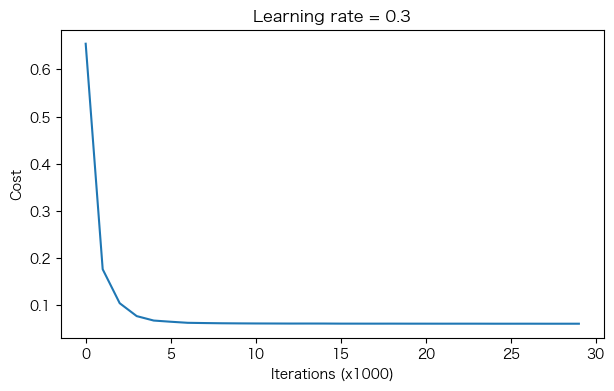

训练集：
准确率: 0.9289099526066351
测试集：
准确率: 0.95


In [38]:
parameters = model(train_X, train_Y, keep_prob=0.86, learning_rate=0.3)
print('训练集：')
predictions_train = predict(train_X, train_Y, parameters)
print('测试集：')
predictions_test = predict(test_X, test_Y, parameters)

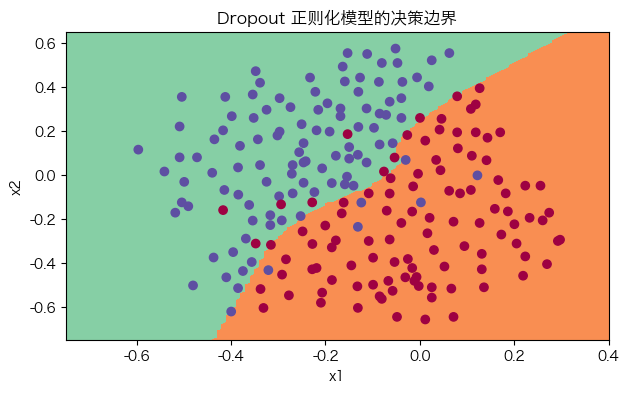

In [39]:
plt.title('Dropout 正则化模型的决策边界')
axes = plt.gca()
axes.set_xlim([-0.75, 0.40])
axes.set_ylim([-0.75, 0.65])
plot_decision_boundary(lambda x: predict_dec(parameters, x.T), train_X, train_Y[0, :])

<a name='6'></a>
## 6 - 总结与对比

下表汇总了三个模型在网络流量异常检测任务上的表现：

| 模型 | 训练集准确率 | 测试集准确率 |
|------|------------|------------|
| 无正则化（基线） | 94.8% | 91.5% |
| L2 正则化（λ=0.7） | 93.4% | 93.5% |
| Dropout（keep_prob=0.86） | 92.8% | 95.0% |

**关键结论：**

1. **无正则化**模型在训练集上表现很好，但测试集准确率偏低，说明发生了**过拟合**
2. **L2 正则化**使决策边界更平滑，训练集准确率略有下降，但测试集准确率提升
3. **Dropout** 通过随机关闭神经元迫使网络学习冗余表示，测试集准确率最高

**使用建议：**
- L2 正则化适合大多数场景，超参数 $\lambda$ 可通过验证集调优
- Dropout 在大型网络中效果尤为显著，`keep_prob` 通常设为 0.5~0.9
- **注意**：Dropout 只在训练时使用，测试时需关闭（`keep_prob=1`）
- 正则化会轻微降低训练集准确率，这是正常现象，目的是提升泛化能力

🎉 恭喜完成本次正则化实验！你已经掌握了对抗过拟合的两种核心武器：L2 正则化与 Dropout。